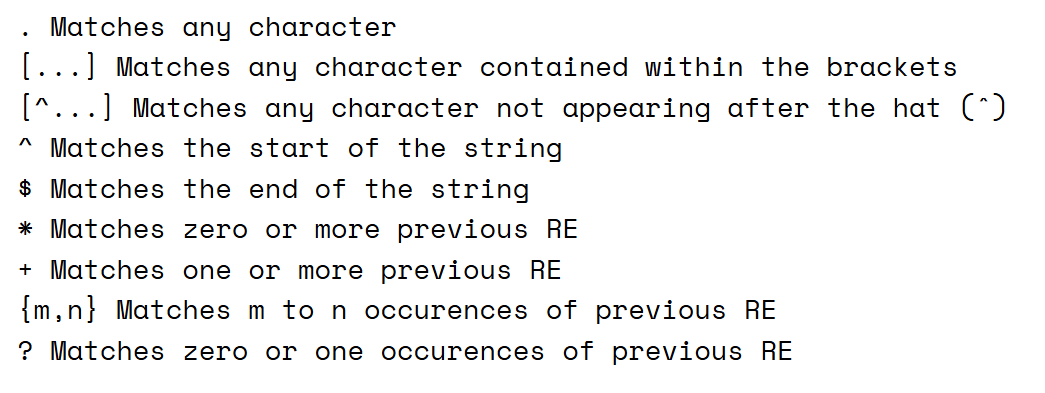

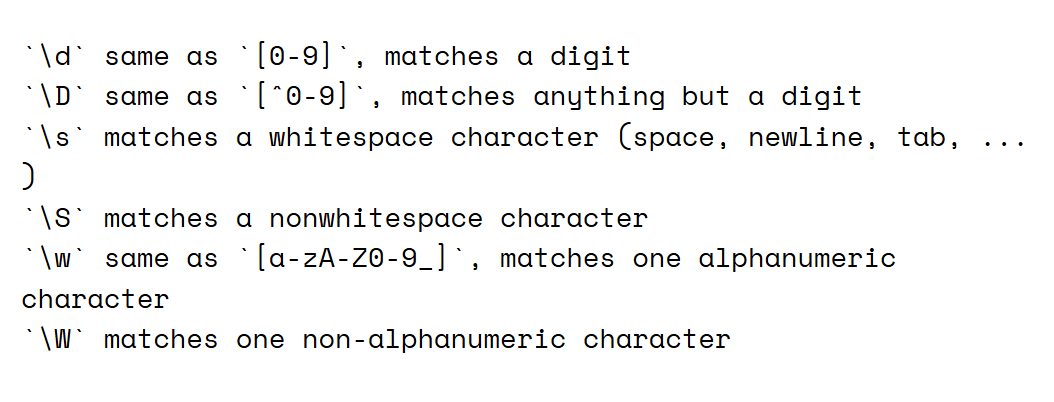

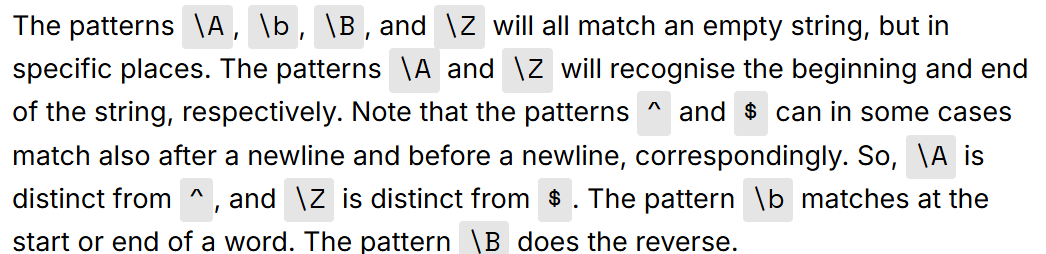

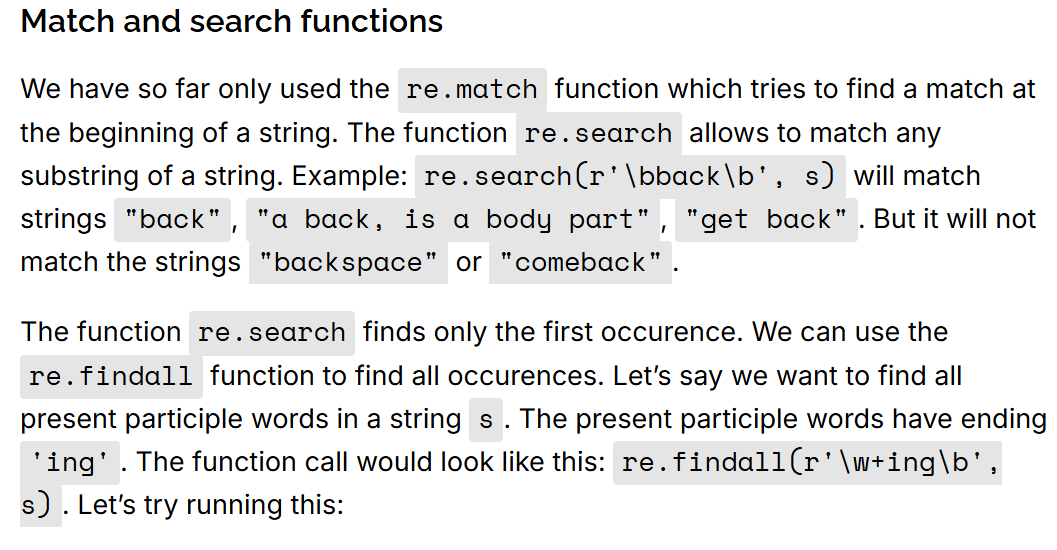

\b at the start: ensures "back" is at the start of a word. <br>
back: matches the literal word "back". <br>
\b at the end: ensures "back" is at the end of a word.

In [1]:
import re
s = "Doing things, going home, staying awake, sleeping later"
re.findall(r'\w+ing\b', s)
# \b did that it ensures that it should end with ing

re.findall(r'[+-]?\d+', "23 + -24 = -1")

s = ("If I’m not in a hurry, then I should stay. " +
    "On the other hand, if I leave, then I can sleep.")
print(re.findall(r'[Ii]f (.*), then', s))

# (.*) is called greedy matching it will match till it can matches

print(re.findall(r'[Ii]f (.*?), then', s)) # this is the non-greddy matching.

re.findall(r'\s*[+-]?\d+', "23 + -24 = -1")


['I’m not in a hurry, then I should stay. On the other hand, if I leave']
['I’m not in a hurry', 'I leave']


['23', ' -24', ' -1']

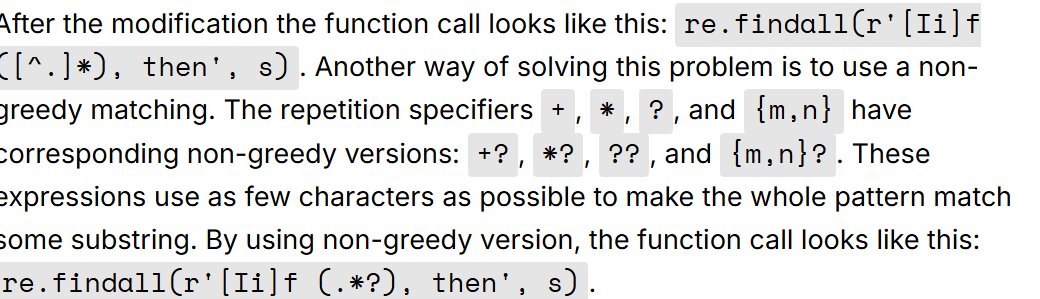

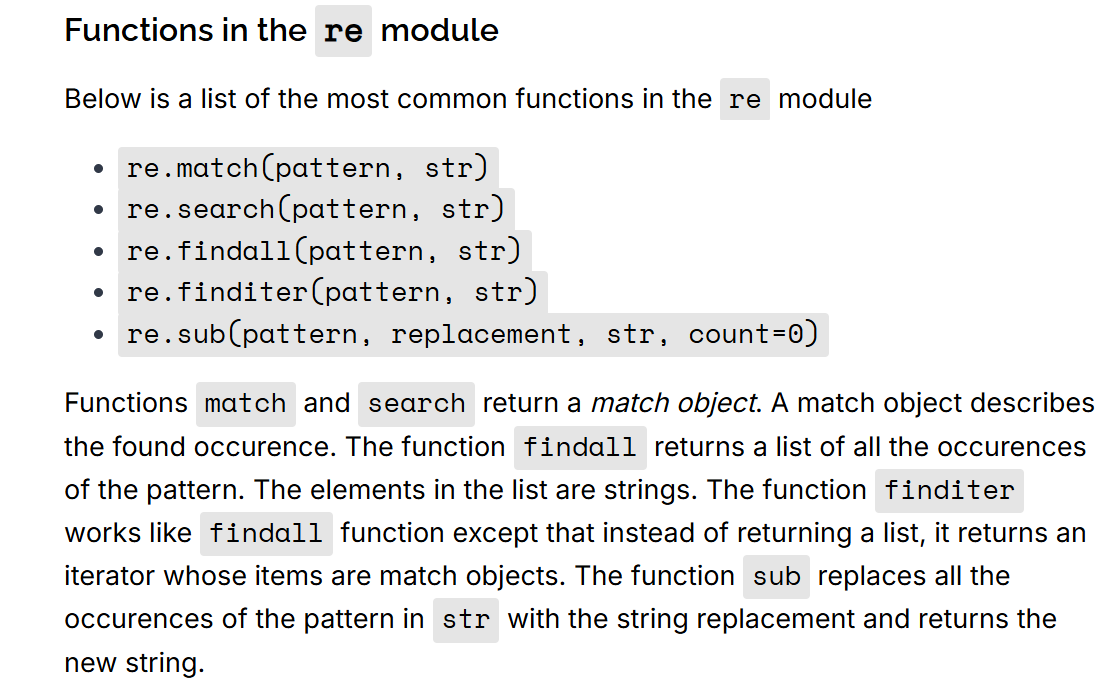

In [6]:
import re
str = "She goes where she wants to, she's a sheriff."
newstr = re.sub(r'\b[Ss]he\b', 'he', str)
print(newstr)

he goes where he wants to, he's a sheriff.


In [10]:
import re
s = "He is a timelord."
print(re.sub(r'(\b[Hh]e\b)', r'\1 (The Doctor)', s))
# Output: He (The Doctor) is a timelord.

s = "cat"
print(re.sub(r'(cat)', r'\1 \1', s))
# Output: cat cat

s = "hello world"
print(re.sub(r'(\w+) (\w+)', r'\2 \1', s))
# Output: world hello

s = "abcabc"
print(bool(re.match(r'(abc)\1', s)))
# Output: True


He (The Doctor) is a timelord.
cat cat
world hello
True


In [11]:
# Parentheses () in a regex pattern create groups.

# Each group can be accessed by its index: group 1, group 2, etc.

# Group 0 always refers to the entire match.

# mo.groups() returns a tuple of all matched groups (excluding group 0).

# mo.group(n) returns the string matched by the nth group.

mo = re.search(r'\d+ (\d+) \d+ (\d+)', 'first 123 45 67 890 last')
print(mo.groups())      # ('45', '890')
print(mo.group(1))      # '45'
print(mo.group(0))      # '123 45 67 890'


('45', '890')
45
123 45 67 890


In [14]:
s = "Alice: alice@example.com, Bob: bob@example.com"
for mo in re.finditer(r'(\w+)@(\w+)\.(\w+)', s):
    print(f"Email: {mo.group(0)}")
    print(f"Username: {mo.group(1)}")
    print(f"Domain: {mo.group(2)}")
    print(f"TLD: {mo.group(3)}")
    print(f"Position: {mo.span(0)}")

print(mo.start(0))  # Output: 17
print(mo.end(0))    # Output: 34
print(mo.start(1))  # Output: 17
print(mo.end(1))    # Output: 22


Email: alice@example.com
Username: alice
Domain: example
TLD: com
Position: (7, 24)
Email: bob@example.com
Username: bob
Domain: example
TLD: com
Position: (31, 46)
31
46
31
34


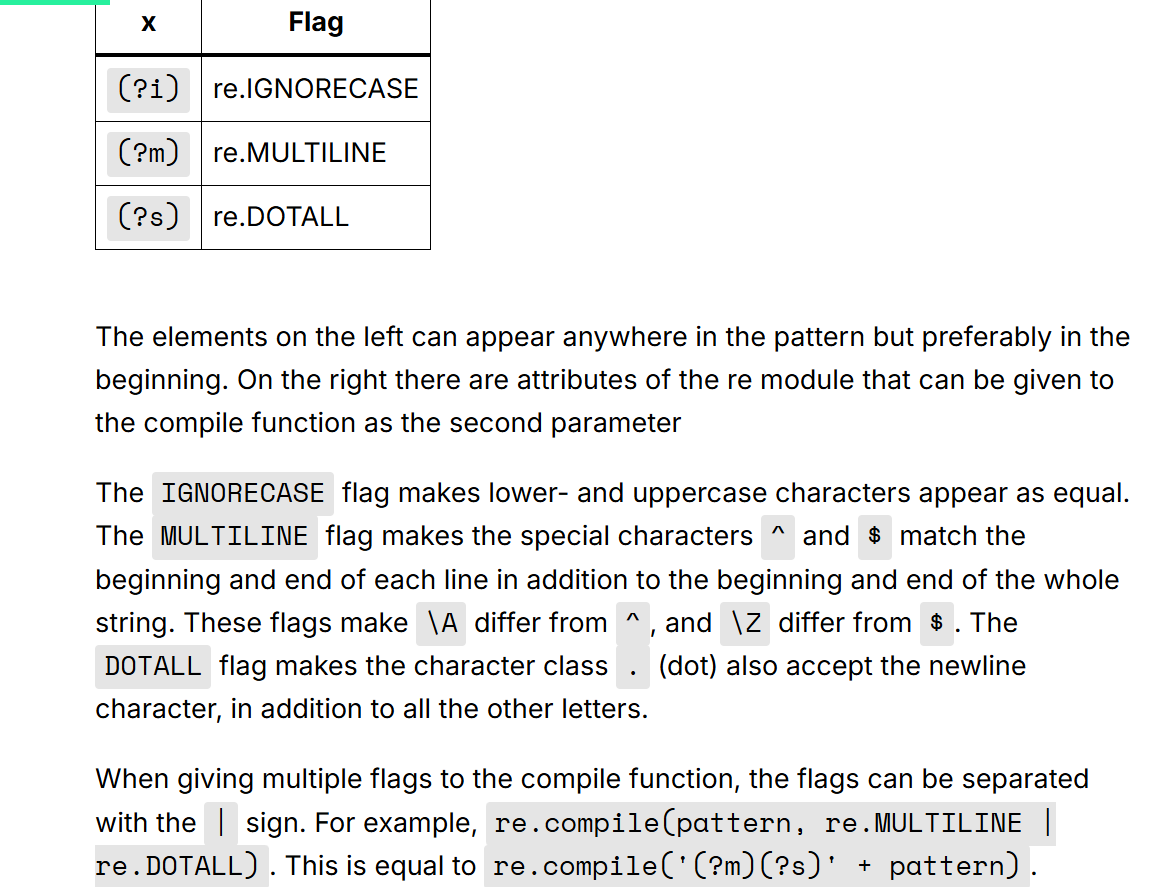

In [ ]:
open(file="",mode="r")

# A file can be opened with the open function. The call open(filename, mode="r") will return a
#  file object, whose type is file. This file object can be used to refer to a file on disk.
#  For example, when we want to read from or write to a file, we can use the methods read and write of the file object. 
# After the file object is no longer needed, a call to the close method should be made.

# In the end of the mode string either the letter t or b can be appended. 
# These stand for text mode and binary mode. If this letter is not given, the file type is text mode by default.

# For binary mode the contents of the file are not interpreted in any way, and the read and write methods handle bytes. 
# (A byte consists of 8 bits and can be used to represent a number in the range 0 to 255.


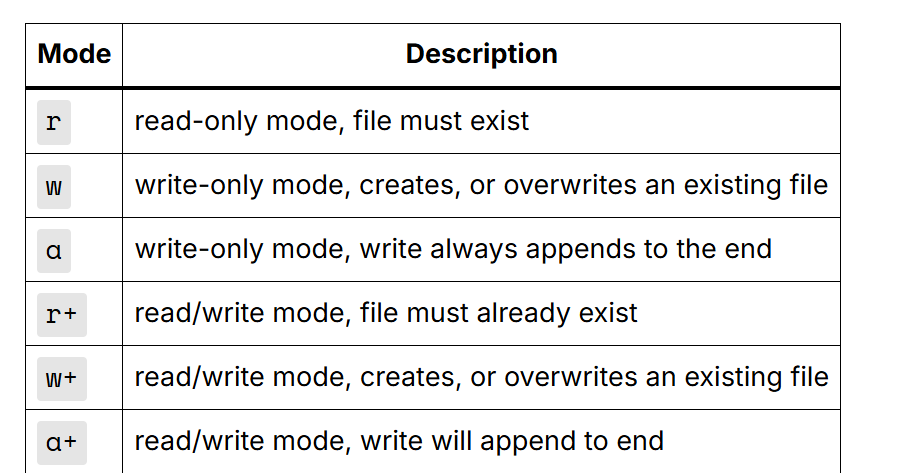

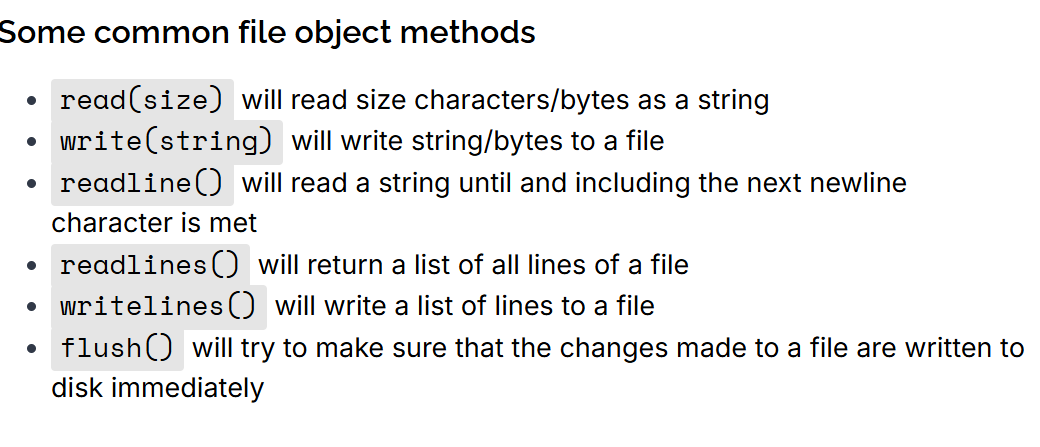

In [ ]:
f = open("basics.ipynb", "r") # Let's open this notebook file, 
                              # which is essentially a text file.
                              # So you can open it in a texteditor as well.
        
for i in range(5):            # And read the first five lines
    line = f.readline()
    print(f"Line {i}: {line}", end="")
f.close()

In [ ]:
# It is easy to forget to close the file. One can use a context manager to solve this problem. 
# A context manager is created with the with statement.
#  After the indented block of the with statement exits, the file will be automatically closed

with open("basics.ipynb", "r") as f:          # the file will be automatically closed,
                                              # when the with block exits
    for i in range(5):
        line = f.readline()
        print(f"Line {i}: {line}", end="")

# by using open it will give teh file type objects which can be looped.

In [ ]:
max_len = 0
with open("basics.ipynb", "r") as f:
    for line in f:    # iterates through all the lines in the file
        if len(line) > max_len:
            max_len = len(line)
print(f"The longest line in this file has length {max_len}")

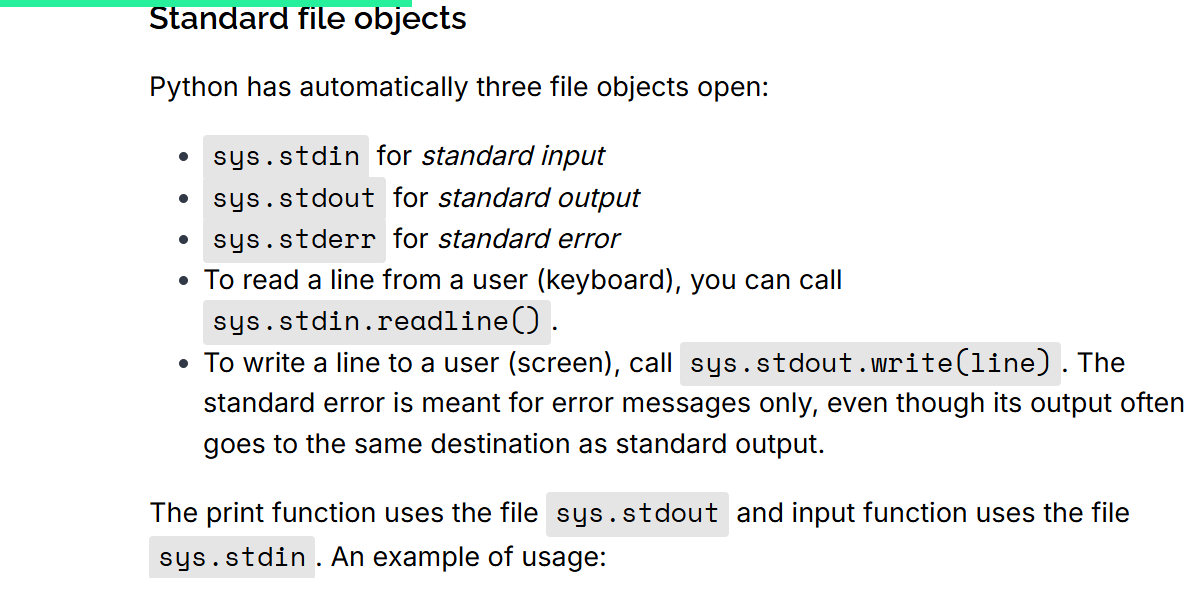

In [11]:
import re
# def file_listing(filename="-rwxr-xr-x 1 jttoivon hyad-all    2356 Dec 11 11:50 add_colab_link.py"):
elements = []
line = "-rwxr-xr-x 1 jttoivon hyad-all    2356 Dec 11 11:50 add_colab_link.py"
matchy = re.match(r"^\S+\s+\d+\s+\S+\s+\S+\s+(\d+)\s+(\w{3})\s+(\d{1,2})\s+(\d{2}):(\d{2})\s+(.*)", line)

print(matchy.groups())



('2356', 'Dec', '11', '11', '50', 'add_colab_link.py')


In [2]:
def red_green_blue(filename="src/rgb.txt"):
    elements = []
    with open (filename,'r') as f:
        next(f) # skip the first line
        for line in f:
            string = ""
            mathcy = re.search(r"\s*(\d{1,3})\s+(\d{1,3})\s+(\d{1,3})\s+(.*)" , line)
            if(mathcy):
                string = f"{mathcy.group(1)}\t{mathcy.group(2)}\t{mathcy.group(3)}\t{mathcy.group(4).strip()}"
                elements.append(string)

    return elements

# In this \s+ means 1 or more whitesapce like it will not be optional so to make 0 or more what we can do is \s*


In [3]:
def word_frequencies(filename):
    di = {}
    with open (filename , 'r') as f:
        
        # so here f is a file object not a sting so to make it in string
        # we do first read and then split as split only works pn string not on object
        ls = f.read().split()
        for l in ls:
            l = l.strip("""!"#$%&'()*,-./:;?@[]_""")

            if l not in di.keys():
                di[l] = 1
            else:
                di[l] = di[l] + 1
            
    return di

In [ ]:

import sys

def summary(filename):
    sum = 0
    count = 0
    std = 0
    mean = 0
    sqr = 0

    with open (filename,'r') as f:
        lines = []
        for line in f:
            try:
                lines.append(float(line))
            except ValueError:
                continue 
        for l in lines:
            sum += float(l)
            count+= 1
            mean = sum / count

        for p in lines:
            sqr = (float(p) - mean)**2
            std += sqr

        std = std / (count-1)
        std = std ** 0.5
    return (sum,mean,std)

def main():
    for filename in sys.argv[1:]:
        total, mean, std = summary(filename)
        print(f"File: {filename} Sum: {total:.6f} Average: {mean:.6f} Stddev: {std:.6f}")

if __name__ == "__main__":
    main()

In [ ]:
def file_count(filename):
    line_count = 0
    char_count = 0
    word_count = 0
    with open(filename , 'r') as f:
        char_count = len(f.read())
        # if we do like this then f pointer is lasready at end so 
        # it will give 0 as line count so 
        lines  = f.readlines()
        line_count = len(lines)
        for line in lines:
            word_in_line = line.split()
            word_count += len(word_in_line)
        
    return(line_count,word_count,char_count)

# so we need different things

def file_count(filename):
    line_count = 0
    char_count = 0
    word_count = 0
    with open(filename , 'r') as f:
        content = f.read()
        # if we do like this then f pointer is lasready at end so 
        # it will give 0 as line count so 
    lines  = content.splitlines()
    line_count = len(lines)
    for line in lines:
        word_in_line = line.split()
        word_count += len(word_in_line)
    char_count = len(content)

# In this we wanted to get the total length of text including white spaces that why so


In [6]:

def file_extensions(filename):

    ll = []
    dd = {}
    with open(filename ,'r') as f:
        lines = f.readlines()

        for l in lines:
            l = l.strip()
            if '.' not in l:
                ll.append(l)
            else:
                dp = l.split(".")[-1]
                if dp not in dd:
                    dd[dp] = []
                dd[dp].append(l.strip())
    return (ll, dd)

# .append(x) adds the entire object x as a single element to the list.
# .extend(x) takes an iterable x and adds each element of x to the list.